In [3]:
import pandas as pd

In [4]:
df = pd.read_excel(r"C:\Users\Hp\Downloads\online+retail\Online Retail.xlsx")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df['CustomerID'].nunique()

4372

In [8]:
#Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [9]:
df.shape

(532621, 8)

In [10]:
#Remove transaction with missing CustomerID
df = df.dropna(subset=["CustomerID"])

In [11]:
df.shape

(397924, 8)

In [12]:
#Check for duplicate transactions
df.duplicated().sum()

np.int64(5192)

In [13]:
#remove duplicate transactions
df=df.drop_duplicates()

In [14]:
df.shape

(392732, 8)

In [15]:
#check purchase quantities
(df["Quantity"]<=0).sum()

np.int64(0)

In [17]:
#calculate transaction revenue
df["Revenue"]=df["Quantity"]*df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [19]:
#calculate total spending per customer
monetary = df.groupby("CustomerID")["Revenue"].sum()
monetary.head()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: Revenue, dtype: float64

In [23]:
#calculate customer recency
latest_purchase = df.groupby("CustomerID")["InvoiceDate"].max()
reference_date = df["InvoiceDate"].max()
recency = (reference_date - latest_purchase).dt.days
recency.head()

CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
Name: InvoiceDate, dtype: int64

In [25]:
#calculate customer frequency
frequency=df.groupby("CustomerID")["InvoiceNo"].nunique()
frequency.head()

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: InvoiceNo, dtype: int64

In [26]:
# Create customer RFM table

rfm = pd.concat([recency, frequency, monetary], axis=1)

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [39]:
# Create RFM scores

rfm["R_score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,325,1,77183.60,1,1,4,6,At Risk
12347.0,1,7,4310.00,4,4,4,12,VIP
12348.0,74,4,1797.24,2,3,4,9,At Risk
12349.0,18,1,1757.55,3,1,4,8,Regular
12350.0,309,1,334.40,1,1,2,4,At Risk


### Customer Segmentation

Customers were segmented using RFM scores. Customers with low recency scores were classified as At Risk, while high RFM scores were classified as VIP. Loyal and Regular customers were identified based on their overall RFM scores.

In [ ]:
# Create customer segments

rfm["RFM_Score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

rfm["Segment"] = "Regular"

rfm.loc[rfm["R_score"] <= 2, "Segment"] = "At Risk"
rfm.loc[rfm["RFM_Score"] >= 10, "Segment"] = "VIP"
rfm.loc[(rfm["R_score"] >= 3) & (rfm["F_score"] >= 3) & (rfm["RFM_Score"] < 10), "Segment"] = "Loyal"

rfm.head()

In [31]:
# Analyze customer segments

rfm["Segment"].value_counts()

Segment
At Risk    2069
VIP        1260
Regular     650
Loyal       360
Name: count, dtype: int64

In [32]:
# Top 10 customers by spending

rfm.sort_values("Monetary", ascending=False).head(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
14646.0,1,74,280206.02,4,4,4,12,VIP
18102.0,0,60,259657.30,4,4,4,12,VIP
17450.0,7,46,194390.79,4,4,4,12,VIP
16446.0,0,2,168472.50,4,2,4,10,VIP
14911.0,0,201,143711.17,4,4,4,12,VIP
12415.0,23,21,124914.53,3,4,4,11,VIP
14156.0,9,55,117210.08,4,4,4,12,VIP
17511.0,2,31,91062.38,4,4,4,12,VIP
16029.0,38,63,80850.84,3,4,4,11,VIP


In [33]:
# Identify high-value customers who are At Risk

rfm[rfm["Segment"] == "At Risk"].sort_values("Monetary", ascending=False).head(10)

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,325,1,77183.60,1,1,4,6,At Risk
15749.0,234,3,44534.30,1,3,4,8,At Risk
15098.0,181,3,39916.50,1,3,4,8,At Risk
12409.0,78,3,11072.67,2,3,4,9,At Risk
12590.0,210,2,9864.26,1,2,4,7,At Risk
13093.0,275,8,7832.47,1,4,4,9,At Risk
12435.0,79,2,7829.89,2,2,4,8,At Risk
12980.0,157,9,7374.90,1,4,4,9,At Risk
16182.0,71,4,6617.65,2,3,4,9,At Risk


In [34]:
# Revenue by customer segment

rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

Segment
VIP        6819332.770
At Risk    1490183.473
Regular     313236.710
Loyal       264455.941
Name: Monetary, dtype: float64

<Axes: title={'center': 'Customer Segment Distribution'}, xlabel='Segment'>

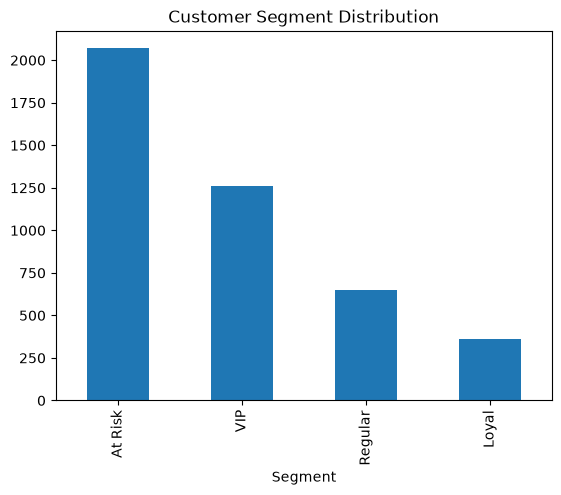

In [35]:
# Customer segment distribution

rfm["Segment"].value_counts().plot(kind="bar", title="Customer Segment Distribution")

<Axes: title={'center': 'Revenue by Customer Segment'}, xlabel='Segment'>

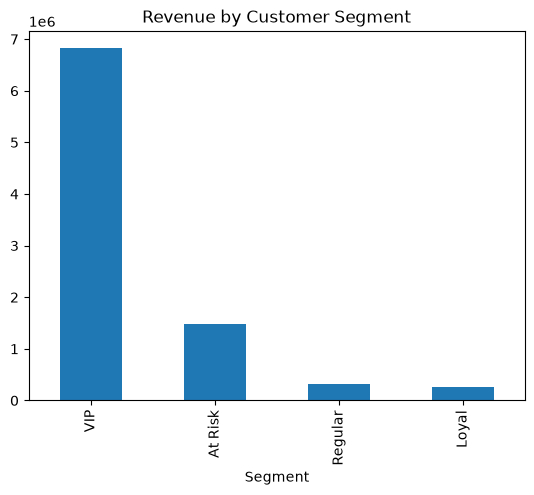

In [36]:
# Revenue by customer segment

rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False).plot(
    kind="bar",
    title="Revenue by Customer Segment"
)

<Axes: title={'center': 'Average Recency by Customer Segment'}, xlabel='Segment'>

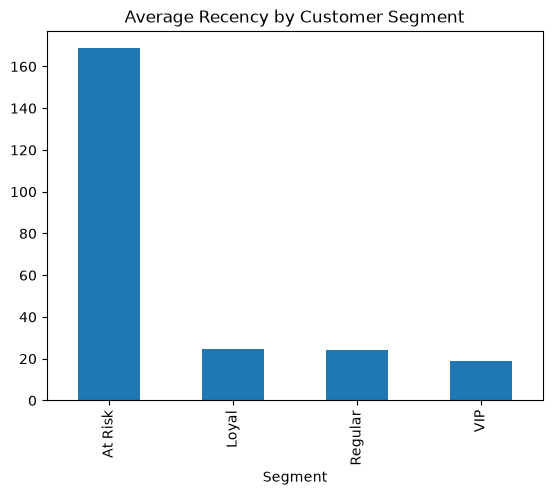

In [37]:
# Average recency by customer segment

rfm.groupby("Segment")["Recency"].mean().sort_values(ascending=False).plot(
    kind="bar",
    title="Average Recency by Customer Segment"
)

In [38]:
# Customer risk percentage

at_risk_percentage = (rfm["Segment"].value_counts(normalize=True) * 100).round(2)

at_risk_percentage

Segment
At Risk    47.68
VIP        29.04
Regular    14.98
Loyal       8.30
Name: proportion, dtype: float64

# Final Insights & Recommendations

## Key Insights

1. Almost 48% of customers are classified as At Risk, indicating a significant customer-retention concern.

2. VIP customers generate the highest total revenue, making them the most valuable customer segment.

3. At Risk customers have the highest average recency, meaning they have not purchased for a longer period.

4. VIP customers show much lower recency, indicating more recent purchasing activity.

5. The business has a large opportunity to convert At Risk customers back into active customers through targeted retention campaigns.

## Recommendations

- Launch targeted offers and personalized campaigns for At Risk customers.
- Reward VIP customers with loyalty benefits to maintain their engagement.
- Monitor customer recency regularly to identify customers becoming inactive.
- Use customer segments to personalize marketing campaigns and retention strategies.